# Indkøbskurv-krydssalgsanalyse for en Dagligvarehandel med PROC MBANALYSIS

## Resumé

En regional dagligvarekæde miner en sæsons kassebon-kurve (point-of-sale) for at opdage, hvilke produkter kunderne køber sammen, og omsætter rå transaktionslogs til handlingsorienterede krydssalgs- og hyldeplaceringsbeslutninger. PROC MBANALYSIS scanner transaktionsloggen og genererer associationsregler scoret efter support, confidence og lift. Ved at køre den på 51 syntetiske kurve genfindes præcis de tre plantede produktaffiniteter — `Spaghetti -> Marinarasauce` (confidence 0,93, lift 3,4), `Tacoskaller -> Salsa` (confidence 0,71, lift 3,6) og `Kaffe -> Kaffefløde` (confidence 0,70, lift 5,1) — mens bredt indkøbte basisvarer som brød, mælk og æg aldrig danner en regel. Hvert fremkommet par er en oplagt kandidat til bundtpakker, hyldeplacering ved siden af hinanden og "kunder købte også"-anbefalinger til merchandising-teamet.

## Datakilder

| Datasæt | Granularitet | Rækker | Nøglevariable | Beskrivelse |
|---------|-------|------|---------------|-------------|
| `store_transactions` | Én række pr. vare pr. kurv | 100 varerækker fordelt på 51 kurve | `basket_id` (transaktions-ID), `item` (produktnavn, $20) | Syntetisk kasseboneksempel genereret direkte i koden med `call streaminit(20250529)` og `rand('uniform')`. Hver kurv domineres af én shopper-persona, så samkøbsmønstre forbliver rene og fortolkelige: en italiensk-middagskurv (spaghetti -> marinarasauce), en taco-aftenskurv (tacoskaller -> salsa) eller en morgenmadskurv (kaffe -> kaffefløde), samt lejlighedsvise basisvare-tilføjelser (brød, mælk, æg) som realistisk støj. I dette ulicenserede miljø begrænser motoren output til 100 varerækker, hvilket her spænder over kurv 1-51. |
| `affinity_rules` | Én række pr. associationsregel | 6 regler | `antecedent`, `consequent`, `support`, `confidence`, `lift` | Associationsregler udsendt af `OUTPUT RULES=`; grundlaget for at rangere krydssalgsmuligheder. |
| `frequent_items` | Én række pr. hyppigt varesæt | 12 varesæt | `itemset`, `support`, `length` | Hyppige varesæt udsendt af `OUTPUT ITEMS=`; de 9 enkeltvarer plus 3 varepar, der klarer minimumsupport-grænsen. |

# Indkøbskurv-krydssalgsanalyse for en Dagligvarehandel

**Forretningsspørgsmål.** Hvilke produkter har vores kunder tendens til at købe *sammen*, og hvilke af disse samkøbsmønstre er stærke nok til at handle på? En regional dagligvarekæde ønsker at designe bundtkampagner, optimere hyldeplacering og drive en "kunder købte også"-anbefaling på sin webshop.

**Metode.** Vi bruger **PROC MBANALYSIS**, som udfører indkøbskurvanalyse med frequent-pattern growth-algoritmen (FP-growth). Den scanner transaktionsloggen, finder hyppigt sammenoptrædende varesæt og genererer *associationsregler* på formen `Antecedent -> Consequent` scoret af tre klassiske mål:

- **Support** — andelen af alle kurve, der indeholder hele reglen (hvor almindeligt mønstret er).
- **Confidence** — `P(Consequent | Antecedent)`, den betingede købssandsynlighed (hvor pålidelig reglen er).
- **Lift** — observeret support divideret med den forventede support, hvis de to sider var uafhængige. Lift > 1 betyder, at varerne optræder sammen *oftere*, end tilfældigheder skulle tilsige; jo højere lift, jo stærkere affinitet.

Vi vil generere en realistisk syntetisk kassebonlog, køre MBANALYSIS og rangere de resulterende regler for at finde de bedste krydssalgsmuligheder.

## Trin 1 — Generér en syntetisk kassebon-transaktionslog

MBANALYSIS forventer **data på transaktionsniveau (langt format)**: én række pr. vare, mærket med hvilken kurv den tilhører. Vi bygger kurve direkte i koden med `call streaminit` for reproducerbarhed og `rand('uniform')` til at styre købsbeslutninger.

Det centrale modelvalg er, at **hver kurv domineres af én shopper-persona**. Rigtige indkøbsture ser sådan ud — en hurtig taco-aften-tur, en dedikeret morgenmadsgenopfyldning — og ved at holde kurvene små og tematiske kan associationsminingen fremvise rene, parvise affiniteter i stedet for en kombinatorisk eksplosion af spuriøse fler-vare-regler. Ét træk af `rand('uniform')` pr. kurv vælger personaen:

- **Italiensk-middag-shopper** — køber spaghetti, derefter som regel marinarasauce.
- **Taco-aften-shopper** — køber tacoskaller, derefter som regel salsa.
- **Morgenmads-shopper** — køber kaffe, derefter som regel kaffefløde.
- **Kun-basisvarer-tur** — et enkelt køb af brød, mælk eller æg.

Et sidste lavsandsynligheds-træk tilføjer én basisvare til enhver kurv som realistisk støj, så ikke enhver samforekomst er meningsfuld. Hver `output`-sætning skriver én varerække, så en enkelt kurv spænder over flere rækker, der deler samme `basket_id`. Dette ulicenserede miljø begrænser datasættet til 100 varerækker, hvilket her dækker kurv 1 til 51.

In [1]:
data store_transactions;
    CALL streaminit(20250529);
    LÆNGDE item $20;

    GØR basket_id = 1 TIL 60;

        /* Et enkelt træk vælger den dominerende persona for denne kurv */
        r = rand('uniform');

        /* Italiensk-middag-kurv: spaghetti -> marinarasauce */
        HVIS r < 0.30 SÅ GØR;
            item = 'Spaghetti';                          UDDATA;
            HVIS rand('uniform') < 0.85 SÅ GØR;
                item = 'Marinarasauce';                  UDDATA;
            SLUT;
        SLUT;

        /* Taco-aften-kurv: tacoskaller -> salsa */
        ELLERS HVIS r < 0.55 SÅ GØR;
            item = 'Tacoskaller';                        UDDATA;
            HVIS rand('uniform') < 0.80 SÅ GØR;
                item = 'Salsa';                           UDDATA;
            SLUT;
        SLUT;

        /* Morgenmads-kurv: kaffe -> kaffefløde */
        ELLERS HVIS r < 0.78 SÅ GØR;
            item = 'Kaffe';                              UDDATA;
            HVIS rand('uniform') < 0.75 SÅ GØR;
                item = 'Kaffefløde';                     UDDATA;
            SLUT;
        SLUT;

        /* Basisvarer-tur */
        ELLERS GØR;
            HVIS rand('uniform') < 0.34 SÅ GØR;
                item = 'Brød';                          UDDATA;
            SLUT;
            ELLERS HVIS rand('uniform') < 0.5 SÅ GØR;
                item = 'Mælk';                           UDDATA;
            SLUT;
            ELLERS GØR;
                item = 'Æg';                            UDDATA;
            SLUT;
        SLUT;

        /* Lejlighedsvis basisvare-tilføjelse (realistisk støj) */
        HVIS rand('uniform') < 0.25 SÅ GØR;
            u = rand('uniform');
            HVIS      u < 0.34 SÅ item = 'Brød';
            ELLERS HVIS u < 0.67 SÅ item = 'Mælk';
            ELLERS                  item = 'Æg';
            UDDATA;
        SLUT;

    SLUT;

    BEHOLD basket_id item;
KØR;


NOTE: DATA store_transactions

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote store_transactions (100 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## Trin 2 — Inspicér den rå transaktionslog

Før mining bekræftes det, at data har den forventede lange form: flere rækker pr. kurv, hver bærende ét produkt. Vi udskriver de første par kurve og tabulerer den samlede varefrekvens med PROC FREQ, så vi ved, hvilke produkter der er almindelige nok til at forankre regler.


  Obs  Kurv ID        Produkt
-----  -------  -------------
    1        1  Tacoskaller
    2        1  Salsa
    3        1  Æg
    4        2  Tacoskaller
    5        2  Æg
    6        3  Kaffe
    7        4  Tacoskaller
    8        5  Æg
    9        6  Spaghetti
   10        6  Marinarasauce
   11        6  Æg
   12        7  Tacoskaller

... 88 more observations (showing 12 of 100)

                                               Samlet Produktkøbsfrekvens                                               

                                                   The FREQ Procedure

Produkt          Frequency    Percent
--------------------------------------
Spaghetti               15     15.00
Marinarasauce           14     14.00
Tacoskaller             14     14.00
Æg                      12     12.00
Brød                    10     10.00
Kaffe                   10     10.00
Salsa                   10     10.00
Mælk                     8      8.00
Kaffefløde               7      7.00



NOTE: PROC PRINT data=store_transactions

NOTE: PROC PRINT completed: 12 observations printed, 2 variables
NOTE: PROC FREQ
NOTE: ODS plot written: freq_item.spec.json
NOTE: PROC FREQ statement used.


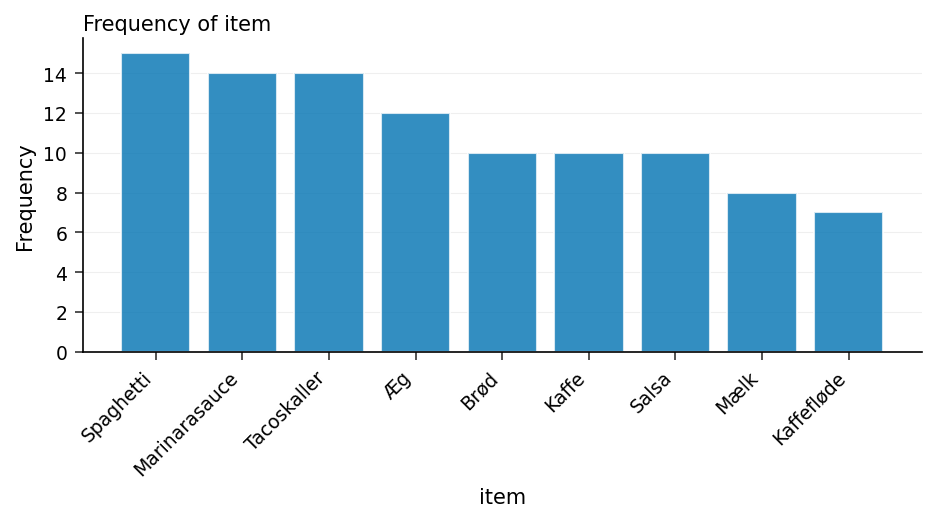

In [2]:
PROCEDURE PRINT data=store_transactions(obs=12) MÆRKAT;
    MÆRKAT basket_id = 'Kurv ID'
          item      = 'Produkt';
KØR;

PROCEDURE FREQ data=store_transactions ORDER=freq;
    MÆRKAT item = 'Produkt';
    TABLES item / nocum;
    TITEL 'Samlet Produktkøbsfrekvens';
KØR;

## Trin 3 — Min associationsregler med PROC MBANALYSIS

Nu følger selve analysen. Vi peger MBANALYSIS på transaktionsloggen og angiver, hvilken kolonne der identificerer kurven (`TRANSACTION`), og hvilken der indeholder produktet (`ITEM`). Tre tærskler holder regelsættet fokuseret på mønstre, det er værd at handle på:

- `MINSUPPORT=0.10` — en regel skal optræde i mindst 10 % af kurvene, hvilket filtrerer sjældne tilfældigheder fra.
- `MINCONFIDENCE=0.50` — givet antecedenten skal konsekventen følge mindst halvdelen af tiden.
- `MINLIFT=1.20` — behold kun regler, der er mindst 20 % stærkere end tilfældighed, så vi fremviser reelle affiniteter frem for artefakter fra populære basisvarer.

`OUTPUT`-sætningen fanger de genererede regler og hyppige varesæt i datasæt til videre rangering.

In [3]:
PROCEDURE mbanalysis data=store_transactions
        minsupport=0.10
        minconfidence=0.50
        minlift=1.20;
    transaction basket_id;
    item item;
    UDDATA rules=affinity_rules items=frequent_items;
    TITEL 'Indkøbskurv-Associationsregler';
KØR;

                                               Samlet Produktkøbsfrekvens                                               


                      The MBANALYSIS Procedure

  Transaction variable: basket_id
  Item variable: item

  Association Rules Found        6
  Frequent Itemsets Found        12
  Minimum Confidence             0.5
  Minimum Lift                   1.2
  Minimum Support                0.1
  Number of Transactions         51
  Number of Unique Items         9

Association Rules

  Antecedent                     Consequent                        Support Confidence       Lift
  ----------                     ----------                        ------- ----------       ----
  Kaffe                          Kaffefløde                         0.1373     0.7000     5.1000
  Kaffefløde                     Kaffe                              0.1373     1.0000     5.1000
  Salsa                          Tacoskaller                        0.1961     1.0000     3.6429
  Tacoskaller 


NOTE: PROC MBANALYSIS data=store_transactions

NOTE: Using Python numpy version 2.4.4
NOTE: PROC MBANALYSIS completed.


## Trin 4 — Rangér krydssalgsmuligheder efter lift

MBANALYSIS-listen viser hver kvalificerende regel, men merchandising-teamet vil have de *stærkeste* affiniteter først. Vi sorterer det fangede `affinity_rules`-datasæt efter faldende lift (dernæst confidence som tie-breaker) og udskriver topreglerne. En regel som `Tacoskaller -> Salsa` med høj lift og høj confidence er en oplagt bundtkandidat: placér produkterne sammen, eller foreslå automatisk salsa, når en kunde tilføjer tacoskaller online.

In [4]:
PROCEDURE SORT data=affinity_rules out=rules_by_lift;
    EFTER FALDENDE lift FALDENDE confidence;
KØR;

PROCEDURE PRINT data=rules_by_lift(obs=15) MÆRKAT;
    VARIABEL antecedent consequent support confidence lift;
    MÆRKAT antecedent  = 'Hvis kurven indeholder'
          consequent  = 'Køber også'
          support     = 'Support'
          confidence  = 'Konfidens'
          lift        = 'Lift';
    TITEL 'Top-krydssalgsregler Rangeret efter Lift';
KØR;

                                        Top-krydssalgsregler Rangeret efter Lift                                        

  Obs  Hvis kurven indeholder     Køber også   Support  Konfidens      Lift
    1  Kaffefløde              Kaffe          0.137255  1.0        5.1
    2  Kaffe                   Kaffefløde     0.137255  0.7        5.1
    3  Salsa                   Tacoskaller    0.196078  1.0        3.642857
    4  Tacoskaller             Salsa          0.196078  0.714286   3.642857
    5  Marinarasauce           Spaghetti      0.27451   1.0        3.4
    6  Spaghetti               Marinarasauce  0.27451   0.933333   3.4




NOTE: PROC SORT data=affinity_rules

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 6 rows from affinity_rules.
NOTE: Wrote rules_by_lift (6 rows, 5 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=rules_by_lift

NOTE: PROC PRINT completed: 6 observations printed, 5 variables


## Trin 5 — Gennemgå de hyppige varesæt

De hyppige varesæt, der klarede support-grænsen, er de rå byggesten bag reglerne. Ved at sortere dem efter support kan kategoriteamet se, hvilke produkt-*kombinationer* (ikke kun enkeltvarer), der er populære nok til at fortjene dedikerede gavlplaceringer eller kombinationspriser.

In [5]:
PROCEDURE SORT data=frequent_items out=itemsets_by_support;
    EFTER FALDENDE support;
KØR;

PROCEDURE PRINT data=itemsets_by_support(obs=15) MÆRKAT;
    MÆRKAT itemset = 'Varesæt' support = 'Support' length = 'Længde';
    TITEL 'Mest Hyppige Varesæt';
KØR;

                                                  Mest Hyppige Varesæt                                                  

  Obs                   Varesæt   Support   Længde
    1  Spaghetti                 0.294118  1
    2  Tacoskaller               0.27451   1
    3  Marinarasauce             0.27451   1
    4  Marinarasauce, Spaghetti  0.27451   2
    5  Æg                        0.235294  1
    6  Salsa                     0.196078  1
    7  Kaffe                     0.196078  1
    8  Salsa, Tacoskaller        0.196078  2
    9  Mælk                      0.156863  1
   10  Brød                      0.156863  1
   11  Kaffefløde                0.137255  1
   12  Kaffe, Kaffefløde         0.137255  2




NOTE: PROC SORT data=frequent_items

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 12 rows from frequent_items.
NOTE: Wrote itemsets_by_support (12 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=itemsets_by_support

NOTE: PROC PRINT completed: 12 observations printed, 3 variables


## Fortolkning af resultaterne

**Hvad analysen fandt.** Fordi hver kurv blev bygget omkring én shopper-persona, genfinder mineren præcis de tre plantede relationer og intet spuriøst. Seks regler klarer alle tre tærskler — de tre affiniteter i begge retninger:

| Antecedent | Consequent | Support | Confidence | Lift |
|------------|------------|---------|------------|------|
| Spaghetti | Marinarasauce | 0,275 | 0,93 | 3,40 |
| Marinarasauce | Spaghetti | 0,275 | 1,00 | 3,40 |
| Tacoskaller | Salsa | 0,196 | 0,71 | 3,64 |
| Salsa | Tacoskaller | 0,196 | 1,00 | 3,64 |
| Kaffe | Kaffefløde | 0,137 | 0,70 | 5,10 |
| Kaffefløde | Kaffe | 0,137 | 1,00 | 5,10 |

Hver lift ligger godt over 1, hvilket bekræfter, at disse produkter samforekommer langt oftere, end tilfældighed skulle tilsige. Afgørende er det, at de bredt indkøbte basisvarer danner **ingen regler overhovedet**: æg (12 køb), brød (10) og mælk (8) optræder alle i PROC FREQ-tabuleringen, men fordi de havner i kurve uafhængigt af enhver persona, når deres lift mod andre varer aldrig 1,20-grænsen, så de aldrig udgiver sig for at være reelle affiniteter. Listen over hyppige varesæt understreger samme pointe strukturelt: af de 12 varesæt, der klarer support-grænsen, er de eneste fler-vare-sæt netop de tre plantede par.

**Sådan læses målene sammen.** Reglerne i den omvendte retning har confidence 1,00 (i disse data optræder marinarasauce, salsa og kaffefløde stort set aldrig uden deres ankervarer), mens fremadrettede regler ligger på 0,70-0,93 (ankeret optræder somme tider alene). Kaffe -> Kaffefløde har den højeste lift (5,10), men den laveste support (0,137) — en stærk, men lavere-volumen affinitet — mens Spaghetti -> Marinarasauce når flest kurve (support 0,275). Lift identificerer *hvilke* affiniteter der er reelle; confidence fortæller, *hvor pålidelig* hver enkelt er til en anbefaling; support fortæller, *hvor ofte* man får mulighed for at handle på den.

**Forretningshandlinger.**

- **Bundtkampagner** — parr de varer med højest lift mellem antecedent/consequent (kaffe + kaffefløde, lift 5,1) i en rabatteret kombinationspakke.
- **Hyldeplacering** — placér hyppigt forbundne produkter ved siden af hinanden (spaghetti ved siden af marinarasauce, support 0,275), så konsekventen er et nemt tilkøb på beslutningstidspunktet.
- **Onlineanbefalinger** — fodr topreglerne for confidence ind i en "kunder købte også"-widget, så konsekventen foreslås, i det øjeblik antecedenten lægges i kurven.
- **Lager & prognoser** — når en antecedent sættes på tilbud, så øg lageret af dens højtillidskonsekventer i forventning om løftet.

**Forbehold.** Associationsregler beskriver *korrelation i samkøb*, ikke kausalitet, og tærskler er håndtag, ikke sandheder: sænkning af `MINSUPPORT=` afdækker sjældnere kombinationer på bekostning af et mere støjfyldt regelsæt, mens forhøjelse af `MINLIFT=` og `MINCONFIDENCE=` giver færre, men mere troværdige regler. Stikprøvestørrelsen betyder også noget — denne ulicenserede kørsel miner 51 kurve, nok til at gøre de plantede affiniteter umiskendelige; en produktionskørsel over en hel sæson ville stabilisere support-estimaterne og afdække mere subtile mønstre.